# 민원 중요도 분류 모델 학습 노트북

이 노트북은 `rule_v3_trainable.csv`로 1차 중요도 분류 모델을 학습하고, 테스트 성능을 확인한 뒤, 직접 민원 문장을 입력해 웹 UI에서 분류 결과를 확인하는 구조입니다.

권장 실행 순서: 위에서 아래로 한 섹션씩 실행하세요.

## 0. 환경 설치

In [1]:
!pip -q install gradio joblib

import os
import json
import time
import joblib
import numpy as np
import pandas as pd

from google.colab import data_table, files

data_table.enable_dataframe_formatter()
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42

## 1. 데이터 경로 설정

큰 파일은 Colab 직접 업로드보다 Google Drive에 올려두고 읽는 쪽이 안정적입니다.

권장 위치:

`/content/drive/MyDrive/데과머/rule_v3_trainable.csv.gz`

압축본이 없으면 `rule_v3_trainable.csv`도 읽을 수 있습니다.

In [2]:
from google.colab import files
import os

print("rule_v3_trainable.csv.gz 또는 rule_v3_trainable.csv 파일을 업로드하세요.")
uploaded = files.upload()

data_path = list(uploaded.keys())[0]

print("업로드 완료")
print("DATA_PATH =", data_path)
print("파일 크기(MB) =", round(os.path.getsize(data_path) / 1024 / 1024, 2))

Mounted at /content/drive
DATA_PATH = /content/drive/MyDrive/데과머/rule_v3_trainable.csv.gz


## 2. 데이터 로드와 분포 확인

In [3]:
use_cols = [
    "Q_refined",
    "importance",
    "urgency",
    "priority_type",
    "cap_reason",
    "evidence_tags",
    "confidence",
    "trainable",
    "needs_review",
]

df = pd.read_csv(
    data_path,
    encoding="utf-8-sig",
    dtype=str,
    usecols=lambda c: c in use_cols,
    low_memory=False,
).fillna("")

df = df[df["Q_refined"].str.strip().ne("")].copy()
df = df[df["importance"].isin(["1", "2", "3", "4", "5"])].copy()

if "trainable" in df.columns:
    df = df[df["trainable"].str.lower().eq("true")].copy()

df["text"] = df["Q_refined"].str.replace(r"\s+", " ", regex=True).str.strip()

print("rows:", len(df))
display(df["importance"].value_counts().sort_index().rename("count").to_frame())
display(df.head(20))

rows: 852648


,count
importance,
1,162477
2,19048
3,599011
4,64942
5,7170


,Q_refined,importance,urgency,priority_type,cap_reason,evidence_tags,confidence,needs_review,trainable,text
0,의창구 #@주소#의 신축건물 때문에 먼지와 소음을 해결해주시기 바랍니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소#의 신축건물 때문에 먼지와 소음을 해결해주시기 바랍니다.
1,의창구에서 #@주소#의 신축건물로 인한 피해가 심각하여 민원을 제기하니 조속한 조치 바랍니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구에서 #@주소#의 신축건물로 인한 피해가 심각하여 민원을 제기하니 조속한 조치 바랍니다.
2,의창구 #@주소# 놀이기구 부속품 유실로 위험한 상황입니다. 확인 후 빠른 보수 요청합니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소# 놀이기구 부속품 유실로 위험한 상황입니다. 확인 후 빠른 보수 요청합니다.
3,의창구 #@주소# 놀이기구 부속품 유실되어 위험해 보입니다. 빠른 정비 요청드립니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소# 놀이기구 부속품 유실되어 위험해 보입니다. 빠른 정비 요청드립니다.
4,의창구 #@주소# 놀이기구 부속품 유실로 위험해서 민원 올립니다. 확인 후 빠른 보수 바랍니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소# 놀이기구 부속품 유실로 위험해서 민원 올립니다. 확인 후 빠른 보수 바랍니다.
5,의창구 #@주소#의 놀이기구 부속품이 유실되었어요. 위험하니 빨리 보수해주세요.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소#의 놀이기구 부속품이 유실되었어요. 위험하니 빨리 보수해주세요.
6,의창구 #@주소# 놀이기구에 부속품이 안 보여요. 위험하니 확인 후 보수 부탁드려요.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,의창구 #@주소# 놀이기구에 부속품이 안 보여요. 위험하니 확인 후 보수 부탁드려요.
7,놀이기구 부속품 유실되어 조치 요청합니다. 위치는 경상남도 창원시 의창구입니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,놀이기구 부속품 유실되어 조치 요청합니다. 위치는 경상남도 창원시 의창구입니다.
8,경상남도 창원시 의창구에 놀이기구 부속품이 유실되어서 위험합니다. 개선 부탁드립니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,경상남도 창원시 의창구에 놀이기구 부속품이 유실되어서 위험합니다. 개선 부탁드립니다.
9,놀이기구 부속이 유실되어 수리 요청드립니다. 경상남도 창원시 의창구 인근입니다.,3,2,ROUTINE_ACTION,NO_EXPLICIT_HIGH_RISK,ROUTINE_ACTION_REQUEST,0.76,false,true,놀이기구 부속이 유실되어 수리 요청드립니다. 경상남도 창원시 의창구 인근입니다.


## 3. 학습/테스트 데이터 분리

`SAMPLE_N = None`이면 전체 학습 데이터를 사용합니다. 처음 빠르게 확인만 하려면 `SAMPLE_N = 100000`처럼 줄여도 됩니다.

In [4]:
from sklearn.model_selection import train_test_split

SAMPLE_N = None  # 빠른 실험: 100000 / 전체 학습: None
TEST_SIZE = 0.10

work_df = df.copy()
if SAMPLE_N is not None and SAMPLE_N < len(work_df):
    work_df, _ = train_test_split(
        work_df,
        train_size=SAMPLE_N,
        stratify=work_df["importance"],
        random_state=RANDOM_STATE,
    )
    work_df = work_df.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    work_df["text"],
    work_df["importance"],
    test_size=TEST_SIZE,
    stratify=work_df["importance"],
    random_state=RANDOM_STATE,
)

print("train:", len(X_train), "test:", len(X_test))
display(y_train.value_counts().sort_index().rename("train_count").to_frame())
display(y_test.value_counts().sort_index().rename("test_count").to_frame())

train: 767383 test: 85265


,train_count
importance,
1,146229
2,17143
3,539110
4,58448
5,6453


,test_count
importance,
1,16248
2,1905
3,59901
4,6494
5,717


## 4. 모델 학습

첫 모델은 빠르고 튼튼한 기준선입니다.

- 문자 n-gram 기반 벡터화: 한국어 띄어쓰기/오타에 비교적 강함
- `class_weight='balanced'`: 중요도 4/5가 적어서 묻히는 문제 완화
- 확률 출력 가능: 웹 UI에서 점수별 확률 표시

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer
from sklearn.linear_model import SGDClassifier

model = Pipeline([
    (
        "hash",
        HashingVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 5),
            n_features=2**20,
            alternate_sign=False,
            norm=None,
            lowercase=False,
        ),
    ),
    ("tfidf", TfidfTransformer(sublinear_tf=True)),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=12,
            tol=1e-3,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
])

start = time.time()
model.fit(X_train, y_train)
print("training seconds:", round(time.time() - start, 1))
print("classes:", model.classes_)

training seconds: 102.1
classes: ['1' '2' '3' '4' '5']


## 5. 테스트 성능 확인

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

pred = model.predict(X_test)

print("accuracy:", round(accuracy_score(y_test, pred), 4))
print("macro_f1:", round(f1_score(y_test, pred, average="macro"), 4))
print("weighted_f1:", round(f1_score(y_test, pred, average="weighted"), 4))
print()
print(classification_report(y_test, pred, digits=4))

labels = ["1", "2", "3", "4", "5"]
cm = confusion_matrix(y_test, pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
display(cm_df)

accuracy: 0.9533
macro_f1: 0.907
weighted_f1: 0.9538

              precision    recall  f1-score   support

           1     0.8911    0.9542    0.9216     16248
           2     0.9030    0.9486    0.9252      1905
           3     0.9816    0.9552    0.9682     59901
           4     0.9097    0.9460    0.9275      6494
           5     0.7427    0.8494    0.7925       717

    accuracy                         0.9533     85265
   macro avg     0.8856    0.9307    0.9070     85265
weighted avg     0.9551    0.9533    0.9538     85265



,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,15504,129,577,19,19
true_2,6,1807,92,0,0
true_3,1864,47,57220,589,181
true_4,5,14,321,6143,11
true_5,19,4,83,2,609


## 6. 오분류 샘플 확인

In [7]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.values,
    "pred": pred,
})
error_df = error_df[error_df["true"] != error_df["pred"]].copy()

print("errors:", len(error_df))
display(error_df.head(100))

for score in ["1", "2", "3", "4", "5"]:
    part = error_df[error_df["true"] == score].head(30)
    print(f"true importance {score} errors:", len(error_df[error_df["true"] == score]))
    display(part)

errors: 3982


,text,true,pred
11,결핵 검사 문의합니다. 진해보건소 연결 요청합니다.,3,1
13,아파트 장애인 주차구역에 일반차량을 지속적으로 주차를 하고 있으니 단속바랍니다.,3,4
17,창원시의 태권도장 신고의무자 교육 관련 문의해요.,3,1
70,창원 음식점 영업 신고 어디로 전화해야 하나요?,3,5
78,세대주 대신 배우자가 대리인으로 방문하여 전입신고 신청하려고 합니다. 방문시 필요한 구비서류 문의드립니다.,3,1
...,...,...,...
2115,진해 오수처리 담당자 문의드립니다.,3,1
2121,진해구청 주정차 과태료 확인 해주세요.,1,3
2157,"공영주차장을 지도 점검 해주세요.경차라고 말하기 전에는 항상 일반 요금을 이야기하하며, 주차 영수증에는 차량번호도 없이 입고 시간만 기록되어 있으며, 출차 시간도 없이 주차관리원이 전화해 주차비 정산을 해달라는 말만 합니다.",1,3
2210,의창 #@주소# 사무실 앞쪽에 악취 차단을 위한 2단으로 된 침전조 뚜껑이 있는데 파손되어 문의를 드립니다.,1,3


true importance 1 errors: 744


,text,true,pred
92,창원시 가로수 관리 담당부서 알려주세요. 가로수 한그루가 넘어지기 직전에 있어요.,1,2
107,의창구 팔용동 팔용어울림운동장 주차시설에 주차를 하려고 하니 관리자가 운동장 사용 외에는 주차를 못하게 합니다. 낮에는 그 운동장을 이용하는 사람이 없어서 일반 주민들에게 사용하게끔 할 수 있을 거 같은데 주민들을 위해서 만든 시설을 주민들이 사용 못하게 하는 건 잘못된 거 같습...,1,3
284,마산구청 관할 오티스 엘리베이터 관리 문제로 세금계산서 발행 하려합니다. 계산서 날짜에 문의드릴게 있으니 담당자 요청을 바랍니다.,1,3
488,성산구 법인등록면허세 납부 안내 요청합니다.,1,3
732,언제부턴가 동네 쓰레기가 저희 #@주소# 기둥에 저녁에 한가득 모여요. 쓰레기 무덤에서 벗어날 수 있고 깨끗한 #@주소# 되게 도와주세요.,1,3
797,시민교회 앞 소공원에서 중앙고 위 횡단보도까지 가로수 식재 관련 문의는 어느 부서로 연락 드리면 되나요?,1,2
831,#@주소# 2차 입주 지연 문제에 대하여 경상남도 건축과에 문의를 합니다. 시민을 생각하여 도움이 되는 방안을 모색후 회신해 주시길 기대합니다.,1,3
1087,시장님 당선전 선거사무실로 기부한 정치자금기부금 영수증 재발행을 요청합니다.,1,3
1262,창원시 스타벅스 귀산점 앞 도로 건너편에 바다로 통하는 통로가 잠겨있어야 되는데 아예 철문이 파손되어 있어 위험해 보입니다. 확인해 주세요.,1,3
1267,가게 상수도 요금 고지서를 3달 정도받지 못했으니 확인해주시길 바랍니다.,1,3


true importance 2 errors: 98


...

,text,true,pred
11,결핵 검사 문의합니다. 진해보건소 연결 요청합니다.,3,1
13,아파트 장애인 주차구역에 일반차량을 지속적으로 주차를 하고 있으니 단속바랍니다.,3,4
17,창원시의 태권도장 신고의무자 교육 관련 문의해요.,3,1
70,창원 음식점 영업 신고 어디로 전화해야 하나요?,3,5
78,세대주 대신 배우자가 대리인으로 방문하여 전입신고 신청하려고 합니다. 방문시 필요한 구비서류 문의드립니다.,3,1
204,양도소득세 신고 관련으로 성산구 #@주소# 아파트의 최초분양가를 알려면 어디로 문의하나요?,3,1
205,창원시 시민청원 올렸는데 담당자 확인 후 처리되는데 걸리는 시간이 어떻게 되나요?,3,1
210,마산합포구청 5톤이상 건설폐기물 배출신고 어떻게 해햐 하는지 알려주세요.,3,1
221,창원시 성산구 #@주소# 소화전 앞 불법 주정차 차량때문에 사고 위험이 있어 안전사고 예방을 위해 단속 요청드립니다.,3,4
235,농기계 정비교육 관련 창원시에 질의 드립니다.,3,1


true importance 4 errors: 351


,text,true,pred
212,마산합포구 #@주소# 산사태 예방을 위한 사방공사 해주시길 요청 합니다.,4,3
269,경상남도 창원시 마산합포구 해운동 #@주소@# 주차선이 없는 곳 모퉁이에 주차 하여 우회전차량들이 시야확보가 어려워 사고 위험이 큽니다. 단속 바랍니다.,4,3
360,진해구 냉천 사거리 교통이정표와 신호등이 가로수에 가려져 사고위험이 있습니다.,4,2
548,"경상남도 창원시 진해구 남문동 횡단보도, 인도에 불법으로 주정차되어 사고의 위험성이 있어 신고합니다.",4,3
1033,경상남도 창원시 마산회원구 #@주소# 불법 주정차 되어 있는큰 차에 가려 내려오는 차가 안 보여 위험하고 골목에서 도로 진입하기가 너무 힘들어 신고하오니 확인 후 처벌 바랍니다.,4,3
1146,"죽전낚시터쪽에서 내려오는 차와 고연공단쪽에서 나오는 차들이 합류하여 지는 지점에다가 상습적으로 화물차나 차량들을 주차하여 놓고 있습니다 이 주차된 차량으로 인해 죽전 1길에서 내려오는 차와 올라가려는 차,고연공단쪽에 나오는 차량들이 뒤섞여 사고의 위험이 아주 큽니다 강력한 주차단...",4,3
1293,"#@주소# 부근 가로수가 인도 쪽으로 처짐이 과해 자전거 주행이나 보행 시에 시야 확보가 어렵고, 무심코 달려가다 사고 날 위험도 있습니다. 조치 바랍니다.",4,2
1382,횡단보도 불법 주정차 차량으로 인해 보행자가 위험하여 신고합니다. 단속해 주세요. 위반 위치는 경상남도 창원시 마산합포구 #@주소#입니다.,4,3
2353,"마산 5번 국도에서 신감, 감천으로 빠지는 길에 좌회전하는 차량이 하루에 몇백대지만 현수막에 가려서 오는 차량이 안 보여서 위험하니 신속히 제거 바랍니다.",4,3
2840,용호동 용호초 후문 가는 도로 곡각지에 #@번호#에 SM 차량이 스쿨존 도로에 장시간 불법 주차를 하고 있어 단속을 신청합니다. 견인조치나 과태료 부탁드립니다.,4,3


true importance 5 errors: 108


,text,true,pred
1221,"5년내 성산구 토월동 관내에서 조상땅 찾기를 한 토지 중 이#@이름#, 이#@이름# 명의제공 명세가 있었는지 문의합니다.",5,1
2362,경상남도 창원시의 성산구 #@주소# 구름다리(철봉) 노후로 붕괴 위험합니다. 신속히 정비 바랍니다.,5,3
2640,2021년 4월 1일 오후 5시경 사회적 거리두기 1.5단계를 연장한다는 관련 공문을 받았구요. 읽어보니 정확한 기준이나 방법은 제시하지 않고 협박적으로 지키지 않으면 처분을 내리겠다는 말이 적혀있어 상당히 불쾌했습니다. 이런 공문을 보낸 창원시에게 사과를 바라는 바입니다.,5,3
2673,"#@주소# 일원은 주거 밀집 지역이며 교육 지역입니다. 군사보호시설이기도 한 이 지역에 회 센터가 말이 안되죠. 4층 건물로 인해 바람과 햇빛, 조망권 모두 침해될 것이니 회 센터 설치를 재검토해 주세요.",5,3
3045,"보안등 #@주소# 위쪽 교통 표지판 뒤와 보안등 아래 콘센트 두개, 맞은편 경남은행 앞 전봇대에 콘센트를 통해 전기를 끌어다 쓰는데 그것도 문제지만 콘센트가 길버닥에 널브러져 있어 감전사고의 위험이 있으니 확인 후 조치해주세요.",5,3
3489,경상남도 창원시 진해구 #@주소# 충장로 주택가 사거리 음식점에 불법 광고 배포물 여러 개가 부착되어 있으므로 수거 바랍니다.,5,3
3742,창원시 창원시 소방용수 표지판과 경계석입니다. 소화전을 찾을 수가 없습니다. 검토바랍니다.,5,3
4634,경상남도 창원시 성산구 #@주소# 에 있는 25국도 교차로 오르막길 주변 우수가 빗물 도로상으로 유입됨에 따라 도로안전에 위험과 침수 등이 예상되오니 정비 요청합니다.,5,3
4949,가스충전소 입구에서 합포구청 방향 약 50m구간에 가드레일이 없고 도로 폭이 좁으며 특히 야간에 도로 경계가 불분명하여 차량 추락시 사고의 위험이 높습니다. [처리요청기관]:창원시,5,3
5100,우천 시 횡단보도 대기 중 감전 안전사고 발생 우려되니 덕산동 방향 골프장 다리 건너기 전 신호등 기둥의 전기 안전커버를 방수 처리 해주시길 바랍니다.,5,3


## 7. 모델 저장

In [8]:
MODEL_DIR = os.path.join(DRIVE_DIR, "complaint_priority_model_v1") if USE_GOOGLE_DRIVE else "complaint_priority_model_v1"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "importance_model.joblib")
meta_path = os.path.join(MODEL_DIR, "metadata.json")

joblib.dump(model, model_path)

metadata = {
    "model": "HashingVectorizer + TfidfTransformer + SGDClassifier(log_loss)",
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "classes": list(model.classes_),
    "data_path": data_path,
    "sample_n": SAMPLE_N,
    "random_state": RANDOM_STATE,
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("saved model:", model_path)
print("saved metadata:", meta_path)

saved model: /content/drive/MyDrive/데과머/complaint_priority_model_v1/importance_model.joblib
saved metadata: /content/drive/MyDrive/데과머/complaint_priority_model_v1/metadata.json


## 8. 직접 문장 테스트

In [9]:
LABEL_DESC = {
    "1": "단순 문의/정보 확인",
    "2": "낮은 일반 요청",
    "3": "일반 조치 필요",
    "4": "높은 공공안전/권리/취약계층 민원",
    "5": "생명·보건·재난·안보 등 최우선 민원",
}

def predict_importance(text: str):
    text = str(text or "").strip()
    if not text:
        return "", pd.DataFrame(columns=["importance", "description", "probability"])
    probs = model.predict_proba([text])[0]
    classes = list(model.classes_)
    pred_idx = int(np.argmax(probs))
    pred_label = classes[pred_idx]
    prob_df = pd.DataFrame({
        "importance": classes,
        "description": [LABEL_DESC.get(c, "") for c in classes],
        "probability": probs,
    }).sort_values("probability", ascending=False)
    summary = f"예측 중요도: {pred_label} - {LABEL_DESC.get(pred_label, '')} / 확신도: {probs[pred_idx]:.3f}"
    return summary, prob_df

sample_texts = [
    "자동차세 과태료 납부 가상계좌가 궁금합니다. 납부 방법을 알려주세요.",
    "교차로 옆 나무가 시야를 가려 사고 위험이 있습니다. 제거 바랍니다.",
    "소화전 앞 불법주정차 때문에 화재진압이 어려울 것 같습니다. 견인 부탁드립니다.",
    "예식장 식사 후 여러 사람이 구토와 설사 증상으로 응급실에 갔습니다. 즉시 점검 바랍니다.",
]

for text in sample_texts:
    summary, prob_df = predict_importance(text)
    print("민원:", text)
    print(summary)
    display(prob_df)
    print("-" * 80)

민원: 자동차세 과태료 납부 가상계좌가 궁금합니다. 납부 방법을 알려주세요.
예측 중요도: 1 - 단순 문의/정보 확인 / 확신도: 0.995


,importance,description,probability
0,1,단순 문의/정보 확인,0.994600
4,5,생명·보건·재난·안보 등 최우선 민원,0.003308
3,4,높은 공공안전/권리/취약계층 민원,0.000893
1,2,낮은 일반 요청,0.000704
2,3,일반 조치 필요,0.000496


--------------------------------------------------------------------------------
민원: 교차로 옆 나무가 시야를 가려 사고 위험이 있습니다. 제거 바랍니다.
예측 중요도: 2 - 낮은 일반 요청 / 확신도: 0.500


,importance,description,probability
1,2,낮은 일반 요청,0.499920
3,4,높은 공공안전/권리/취약계층 민원,0.423614
4,5,생명·보건·재난·안보 등 최우선 민원,0.076083
2,3,일반 조치 필요,0.000262
0,1,단순 문의/정보 확인,0.000121


--------------------------------------------------------------------------------
민원: 소화전 앞 불법주정차 때문에 화재진압이 어려울 것 같습니다. 견인 부탁드립니다.
예측 중요도: 5 - 생명·보건·재난·안보 등 최우선 민원 / 확신도: 0.549


,importance,description,probability
4,5,생명·보건·재난·안보 등 최우선 민원,0.548725
2,3,일반 조치 필요,0.427168
3,4,높은 공공안전/권리/취약계층 민원,0.012546
1,2,낮은 일반 요청,0.011222
0,1,단순 문의/정보 확인,0.000340


--------------------------------------------------------------------------------
민원: 예식장 식사 후 여러 사람이 구토와 설사 증상으로 응급실에 갔습니다. 즉시 점검 바랍니다.
예측 중요도: 5 - 생명·보건·재난·안보 등 최우선 민원 / 확신도: 0.577


,importance,description,probability
4,5,생명·보건·재난·안보 등 최우선 민원,0.577287
2,3,일반 조치 필요,0.400534
1,2,낮은 일반 요청,0.015927
0,1,단순 문의/정보 확인,0.003961
3,4,높은 공공안전/권리/취약계층 민원,0.002291


--------------------------------------------------------------------------------


## 9. 웹 UI 실행

아래 셀을 실행하면 Colab 출력에 Gradio 링크가 뜹니다. 그 링크를 열면 민원 내용을 직접 입력해서 중요도 예측을 볼 수 있습니다.

In [13]:
import gradio as gr

def classify_for_web(text):
    summary, prob_df = predict_importance(text)
    if not summary:
        return "민원 내용을 입력하세요.", pd.DataFrame(columns=["importance", "description", "probability"])
    out = prob_df.copy()
    out["probability"] = out["probability"].map(lambda x: round(float(x), 4))
    return summary, out

with gr.Blocks(title="민원 중요도 분류기") as demo:
    gr.Markdown("# 민원 중요도 분류기")
    gr.Markdown("민원 내용을 입력하면 중요도 1~5와 점수별 확률을 보여줍니다.")
    complaint = gr.Textbox(
        label="민원 내용",
        lines=8,
        placeholder="예: 횡단보도 앞 불법주차 차량 때문에 시야가 가려 사고 위험이 있습니다.",
    )
    button = gr.Button("분류하기", variant="primary")
    summary = gr.Textbox(label="예측 결과", lines=2)
    table = gr.Dataframe(label="중요도별 확률", interactive=False)
    button.click(classify_for_web, inputs=complaint, outputs=[summary, table])
    complaint.submit(classify_for_web, inputs=complaint, outputs=[summary, table])

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://003e787113739616b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://003e787113739616b5.gradio.live


## 웹 UI 테스트용 민원 예시

아래 문장을 Gradio 웹 UI에 복사해서 넣고 예측 결과를 확인한다.

| 예상 중요도 | 민원 예시 |
|---|---|
| 1 | 자동차세 납부 고지서를 분실했습니다. 가상계좌와 납부 방법을 어디서 확인할 수 있나요? |
| 1 | 주민등록등본 발급은 온라인으로 가능한가요? 필요한 서류와 절차를 알려주세요. |
| 1 | 주차 위반 과태료를 이미 납부했는데 납부 확인서는 어디서 발급받을 수 있나요? |
| 2 | 집 앞 도로변 잡초가 많이 자라 보기 좋지 않습니다. 제초 작업을 요청드립니다. |
| 2 | 동네 공원 벤치가 오래되어 페인트가 벗겨졌습니다. 정비 부탁드립니다. |
| 2 | 골목길 쓰레기통 주변이 지저분합니다. 청소를 요청드립니다. |
| 3 | 인도에 불법 주차한 차량이 반복적으로 있어 통행이 불편합니다. 확인 후 과태료 부과 부탁드립니다. |
| 3 | 가로등이 며칠째 고장 나 밤길이 어둡습니다. 수리 요청드립니다. |
| 3 | 공사장에서 새벽마다 소음이 심하게 발생합니다. 현장 확인 후 조치 부탁드립니다. |
| 4 | 초등학교 앞 횡단보도에 불법주차 차량이 계속 있어 아이들이 차 사이로 나와 위험합니다. 단속 부탁드립니다. |
| 4 | 교차로 옆 나무가 시야를 가려 차량이 오는지 보이지 않습니다. 사고 위험이 있어 제거 요청드립니다. |
| 4 | 장애인 전용 주차구역을 불법주차 차량이 막고 있어 이용할 수 없습니다. 단속 부탁드립니다. |
| 5 | 소화전 앞에 불법주정차된 차량 때문에 화재 발생 시 소방차 진입과 화재진압이 어렵습니다. 즉시 견인 조치 바랍니다. |
| 5 | 예식장 뷔페 식사 후 여러 사람이 구토와 설사 증상으로 응급실에 갔습니다. 즉시 위생 점검을 해주세요. |
| 5 | 아파트 지하주차장 천장에서 물이 계속 새고 전기 배선 근처라 감전 위험이 있습니다. 긴급 점검 부탁드립니다. |


# 10.혼동행렬 확인하기


,예측 1,예측 2,예측 3,예측 4,예측 5
실제 1,15504,129,577,19,19
실제 2,6,1807,92,0,0
실제 3,1864,47,57220,589,181
실제 4,5,14,321,6143,11
실제 5,19,4,83,2,609


<Figure size 800x600 with 0 Axes>

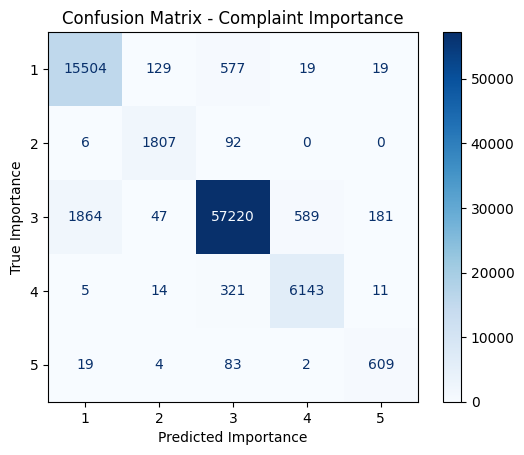

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["1", "2", "3", "4", "5"]

cm = confusion_matrix(y_test, pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"실제 {x}" for x in labels],
    columns=[f"예측 {x}" for x in labels],
)

display(cm_df)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)
disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=True,
)
plt.title("Confusion Matrix - Complaint Importance")
plt.xlabel("Predicted Importance")
plt.ylabel("True Importance")
plt.grid(False)
plt.show()

,예측 1,예측 2,예측 3,예측 4,예측 5
실제 1,0.954,0.008,0.036,0.001,0.001
실제 2,0.003,0.949,0.048,0.000,0.000
실제 3,0.031,0.001,0.955,0.010,0.003
실제 4,0.001,0.002,0.049,0.946,0.002
실제 5,0.026,0.006,0.116,0.003,0.849


<Figure size 800x600 with 0 Axes>

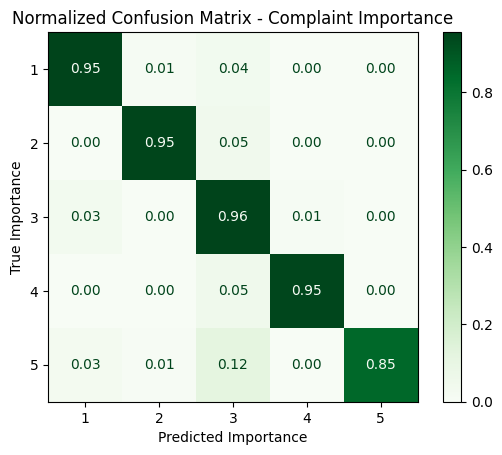

In [12]:
cm_norm = confusion_matrix(
    y_test,
    pred,
    labels=labels,
    normalize="true",
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"실제 {x}" for x in labels],
    columns=[f"예측 {x}" for x in labels],
)

display(cm_norm_df.round(3))

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels,
)
disp.plot(
    cmap="Greens",
    values_format=".2f",
    colorbar=True,
)
plt.title("Normalized Confusion Matrix - Complaint Importance")
plt.xlabel("Predicted Importance")
plt.ylabel("True Importance")
plt.grid(False)
plt.show()